# Daily Challenge — Understanding the Essence of Machine Learning


**Goal of this notebook**
- Summarize what Machine Learning is and why it matters for data analysts.
- List concrete industry applications.
- Compare **Supervised**, **Unsupervised** and **Reinforcement Learning**.
- Describe the three main stages of building an ML model: **Feature Selection**, **Model Selection** and **Model Evaluation**.
- Draw a flowchart of the full ML pipeline.

All comments are in English.

## 1. What is Machine Learning, and why does it matter for data analysts?

**Machine Learning (ML)** is the branch of Artificial Intelligence that builds systems capable of **learning patterns from data** without being explicitly programmed for every case. Instead of writing rules by hand, the data scientist defines a *task*, exposes the model to many examples, and lets a learning algorithm discover the rules that solve the task best.

Concretely, an ML model is a mathematical function with **parameters** that are adjusted during *training* to minimize a *loss* between the predictions and the truth. Once trained, the model can make predictions on new, unseen data.

**Why it matters for a data analyst**
- Modern organisations produce far more data than humans can analyse by hand. ML turns this raw data into **actionable knowledge** (predictions, segments, anomalies).
- It transforms the role of the analyst from describing what *happened* (descriptive analytics) to predicting what *will happen* (predictive analytics) and recommending what to do (prescriptive analytics).
- It scales — once a model is trained, it can score millions of records per second.
- It captures **non-obvious patterns** in complex, high-dimensional data that classical statistics alone cannot reveal.

## 2. Industry applications — three concrete examples

**a) Healthcare — Medical imaging diagnosis.**  
Convolutional neural networks trained on millions of labelled MRI scans, mammograms or chest X-rays can detect tumours, fractures or pneumonia with accuracy comparable to expert radiologists. ML reduces diagnosis time and helps prioritize urgent cases.

**b) Finance — Credit-card fraud detection.**  
Banks process billions of transactions daily. A real-time ML model scores every transaction in milliseconds, flagging suspicious patterns based on amount, location, merchant and customer behaviour. The model retrains continuously because fraudsters adapt.

**c) E-commerce and streaming — Recommendation engines.**  
Amazon, Netflix and Spotify rely on ML to personalise the catalogue shown to each user. Collaborative filtering, matrix factorisation and deep learning models suggest products, films or songs that the user is most likely to buy or watch. Netflix reportedly estimates that its recommender saves more than **$1 billion per year** in retained subscriptions.

Other major application areas include **autonomous driving** (computer vision + sensor fusion + reinforcement learning), **predictive maintenance** in heavy industry (IoT sensors), **natural-language processing** (translation, chatbots, search), and **agriculture** (crop yield forecasting from satellite imagery).

## 3. The three main types of Machine Learning

| Type | Definition | Typical example |
|---|---|---|
| **Supervised Learning** | The model learns from **labelled** data: each training example comes with the correct answer. The goal is to predict that answer on new examples. | **Spam detection** — emails are labelled *Spam / Not Spam*, the model learns to predict the label. **House-price prediction** — historical sales include the actual sale price (regression). |
| **Unsupervised Learning** | The model receives **no labels**. It tries to discover hidden structure: groups of similar records, recurring patterns, low-dimensional representations. | **Customer segmentation** — group e-commerce users by purchase behaviour with K-Means. **Topic modeling** of news articles with LDA. **Anomaly detection** in network traffic. |
| **Reinforcement Learning** | An **agent** interacts with an **environment**, takes actions, receives **rewards** and learns the policy that maximises the cumulative reward over time. | **Game AI** — AlphaGo, AlphaZero. **Robotics** — a robot arm learns to grasp objects. **Autonomous driving** — adaptive cruise control. |

### How to recognise the right paradigm
- *"I have labels for the answer I want to predict."* → **Supervised** (classification if labels are discrete, regression if continuous).
- *"I have data but no labels and I want to discover groups or structure."* → **Unsupervised**.
- *"My system has to take a sequence of decisions and gets feedback (reward) from the environment."* → **Reinforcement Learning**.

A fourth paradigm worth mentioning is **Semi-supervised Learning**, useful when only a small fraction of the data is labelled — e.g. medical imaging where labels are expensive.

## 4. The Machine Learning workflow: three core stages

### 4.1 Feature Selection
*Goal:* keep only the input variables that genuinely help the prediction and drop the noise.

- **Why it matters:** irrelevant features inflate variance, increase training time and lead to overfitting (the *curse of dimensionality*).
- **Common methods:**
  - *Filter* — statistical tests (correlation, χ², ANOVA F-value) that score each feature independently.
  - *Wrapper* — Recursive Feature Elimination (RFE), forward / backward selection.
  - *Embedded* — L1 (Lasso) regularisation that pushes useless coefficients to 0, feature importances from tree-based models.
- Includes **feature engineering**: building new derived columns such as ratios, dates parsed into year/month, one-hot encoding of categorical variables, log transformations of skewed features.
- Includes **handling of missing values** and **scaling** when needed.

### 4.2 Model Selection
*Goal:* pick the family of algorithms and the specific hyperparameters that best solve the problem.

- Compare candidate families: **Logistic Regression** for an interpretable baseline, **Decision Trees / Random Forests / Gradient Boosting** for tabular data, **Neural Networks** for images, text and audio.
- Use **cross-validation** (k-fold, stratified k-fold) to estimate generalisation performance without touching the test set.
- Tune hyperparameters via **Grid Search**, **Random Search** or **Bayesian optimisation**.
- Apply the **Occam's-razor principle**: if two models perform similarly, choose the simpler / more interpretable one.

### 4.3 Model Evaluation
*Goal:* measure how well the chosen model generalises to *unseen* data and check it is fit for production.

- Evaluate on a **held-out test set** that was never used during training or tuning.
- Pick metrics that match the business question:
  - *Classification* → **Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Confusion Matrix**.
  - *Regression* → **MAE, RMSE, R²**.
  - *Clustering* → **Silhouette, Davies-Bouldin, Elbow method**.
- Look beyond a single number: study **error analysis**, **calibration**, **fairness** across subgroups and **robustness** under data drift.
- Decide on a **deployment threshold** that maps the model output to the business decision.

## 5. Visual flowchart of the ML process

The cell below uses **Matplotlib** to draw a complete pipeline from raw data to deployment.

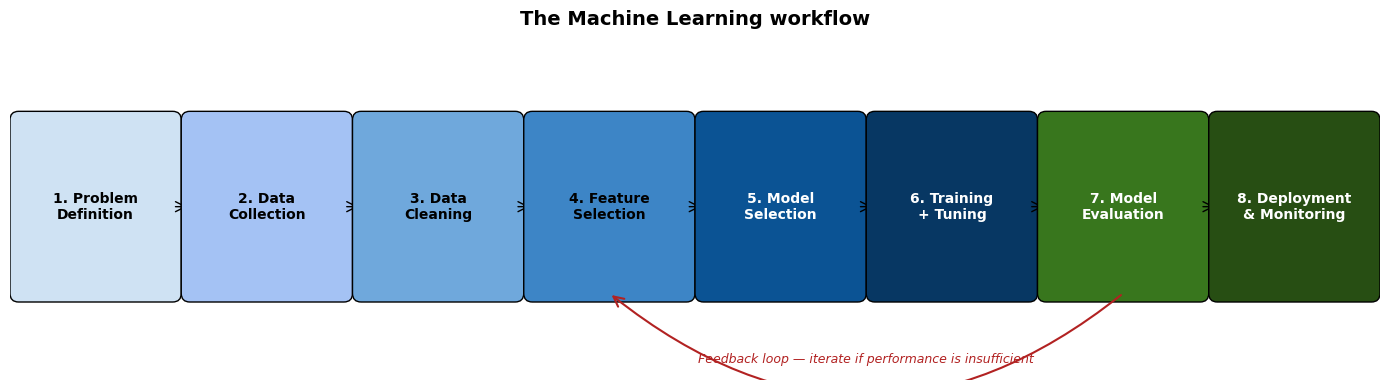

Flowchart saved to: ml_workflow.png


In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

stages = [
    ('1. Problem\nDefinition',     '#cfe2f3'),
    ('2. Data\nCollection',        '#a4c2f4'),
    ('3. Data\nCleaning',          '#6fa8dc'),
    ('4. Feature\nSelection',      '#3d85c6'),
    ('5. Model\nSelection',        '#0b5394'),
    ('6. Training\n+ Tuning',      '#073763'),
    ('7. Model\nEvaluation',       '#38761d'),
    ('8. Deployment\n& Monitoring','#274e13'),
]

fig, ax = plt.subplots(figsize=(14, 4))
ax.set_xlim(0, len(stages))
ax.set_ylim(0, 2)
ax.axis('off')

for i, (label, color) in enumerate(stages):
    box = FancyBboxPatch((i + 0.05, 0.5), 0.9, 1.0,
                         boxstyle='round,pad=0.05',
                         facecolor=color, edgecolor='black')
    ax.add_patch(box)
    text_color = 'white' if i >= 4 else 'black'
    ax.text(i + 0.5, 1.0, label, ha='center', va='center',
            fontsize=10, fontweight='bold', color=text_color)
    if i < len(stages) - 1:
        arrow = FancyArrowPatch((i + 0.95, 1.0), (i + 1.05, 1.0),
                                arrowstyle='->', mutation_scale=18, color='black')
        ax.add_patch(arrow)

# Feedback loop arrow back from Evaluation to Feature Selection
loop = FancyArrowPatch((6.5, 0.5), (3.5, 0.5),
                       connectionstyle='arc3,rad=-0.4',
                       arrowstyle='->', mutation_scale=18,
                       color='firebrick', linewidth=1.5)
ax.add_patch(loop)
ax.text(5.0, 0.10, 'Feedback loop — iterate if performance is insufficient',
        ha='center', fontsize=9, color='firebrick', style='italic')

plt.title('The Machine Learning workflow', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ml_workflow.png', dpi=150, bbox_inches='tight')
plt.show()
print('Flowchart saved to: ml_workflow.png')

## 6. Key takeaways

- **Machine Learning = data + algorithm + evaluation.** Take any of the three away and the project collapses.
- **Three main flavours** — *Supervised* (learn from labels), *Unsupervised* (discover structure), *Reinforcement* (learn from rewards).
- **A good ML model is built iteratively.** Feature Selection → Model Selection → Model Evaluation is not a one-shot pipeline but a **feedback loop** — the evaluation step often sends us back to feature engineering or model tuning.
- **The right metric matters more than the model.** Accuracy on an imbalanced medical dataset is misleading; recall, precision, F1 and PR-AUC tell the real story.
- **Production is part of the job.** A model that works in a notebook but is never monitored in production will silently degrade as the world changes (data drift).

For a data analyst, mastering this workflow is what turns a *report* into a *decision-making system*.

